# Arquitetura de Agentes

## Ambiente

In [1]:
from sys import path

import numpy as np
import matplotlib.pyplot as plt
import collections
import heapq
import random

from matplotlib.pyplot import grid

plt.rcParams['figure.figsize'] = [6,6]
plt.rcParams['image.cmap'] = 'Pastel1'
print('Ambiente configurado')

Ambiente configurado


## Ambiente fisico (Virtual)

In [2]:
class Environment:
    """
    Representa o ambiente físico (dois quartos).
    O estado é definido pela localização da sujeira e do agente
    """
    def __init__(self):
        self.locationCondition = {
            'A': random.choice(['Sujo', 'Limpo']),
            'B': random.choice(['Sujo', 'Limpo'])
        }
        self.clearLocation = random.choice(['A', 'B'])
        print(f"Ambiente Inicializado: {self.locationCondition}, Agente em: {self.clearLocation}")


## Criação do nosso Agente

In [3]:
class SimpleAgent:
    """
    Implementação de um agente reativo simples
    'Inteligência' é um conjunto de regras de produção (if-then)
    """
    def __init__(self, env):
        self.env = env
        self.performance = 0

    def act(self):
        location = self.env.clearLocation
        status = self.env.locationCondition[location]
        print(f"[Percepção] Estou em {location}. O status: {status}")

        action = None
        if status == 'Sujo':
            action = 'ASPIRAR'
        elif location == 'A':
            action = 'MOVER_DIREITA'
        elif location == 'B':
            action = 'MOVER_ESQUERDA'

        if action == 'ASPIRAR':
            self.env.locationCondition[location] = 'Limpo'
            self.performance += 1
        elif action == 'MOVER_DIREITA':
            self.env.clearLocation = 'B'
        elif action == 'MOVER_ESQUERDA':
            self.env.clearLocation = 'A'

        return action


## Ciclo de vida do agente

In [4]:
env_instance = Environment()
agent_instance = SimpleAgent(env_instance)

print('--- Início do Ciclo de Vida do Agente ---')

for i in range(1, 6):
    print(f"Etapas {i}:")
    action = agent_instance.act()
    print(f"[Ação] O agente executou: {action}")
    print("-" * 30)

print(f"\n--- Fim da simulaço: {agent_instance.performance} ---")

Ambiente Inicializado: {'A': 'Sujo', 'B': 'Limpo'}, Agente em: A
--- Início do Ciclo de Vida do Agente ---
Etapas 1:
[Percepção] Estou em A. O status: Sujo
[Ação] O agente executou: ASPIRAR
------------------------------
Etapas 2:
[Percepção] Estou em A. O status: Limpo
[Ação] O agente executou: MOVER_DIREITA
------------------------------
Etapas 3:
[Percepção] Estou em B. O status: Limpo
[Ação] O agente executou: MOVER_ESQUERDA
------------------------------
Etapas 4:
[Percepção] Estou em A. O status: Limpo
[Ação] O agente executou: MOVER_DIREITA
------------------------------
Etapas 5:
[Percepção] Estou em B. O status: Limpo
[Ação] O agente executou: MOVER_ESQUERDA
------------------------------

--- Fim da simulaço: 1 ---


# Busca de espaço

In [5]:
grid_map = [
    [0,0,0,0,0,0,0,1,0,0],
    [0,1,1,0,0,1,0,1,0,0],
    [0,1,0,0,0,1,0,1,1,0],
    [0,0,0,1,1,1,0,0,0,0],
    [0,1,0,0,0,0,0,1,1,0],
    [2,1,0,0,0,0,0,0,1,3],
    [0,0,0,1,1,0,0,0,1,0],
    [0,0,0,0,0,1,0,1,0,0]
]

start_node = (5, 0)
goal_node = (5, 9)

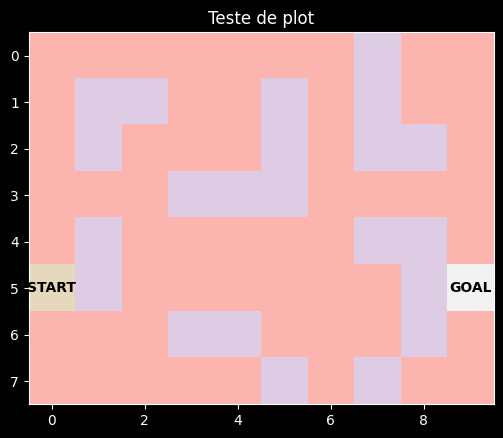

In [6]:
def plot_search_result(grid, path=None, title="Resultado da busca"):
    grid_np = np.array(grid)
    plt.imshow(grid_np)
    plt.title(title)

    for (i, j), value in np.ndenumerate(grid_np):
        if value == 2:
            plt.text(j, i, 'START', ha='center', va='center', fontweight='bold', color='black')
        if value == 3:
            plt.text(j, i, 'GOAL', ha='center', va='center', fontweight='bold', color='black')

    if path:
        y_coords, x_coords = zip(*path)
        plt.plot(x_coords, y_coords, marker='o', color='purple', markersize=10, linewidth=2, label='Caminho ótimo')

plot_search_result(grid_map, title="Teste de plot")
plt.show()

## BFS Busca em Largura

Análise BFS, custo do caminho: 15
Esforço Computacional: 53


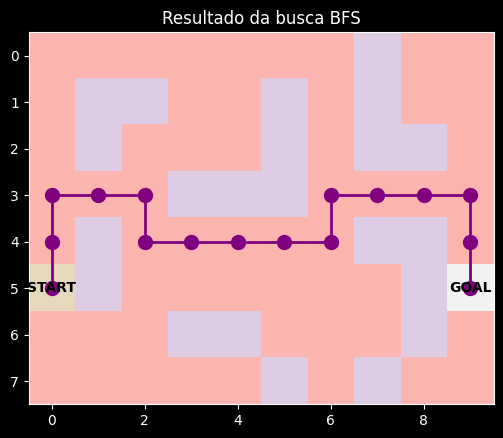

In [7]:
def bfs(grid, start, goal):
    rows , cols = len(grid), len(grid[0])
    queue = collections.deque([[start]])

    seen = set([start])
    nodes_explored_count = 0

    while queue:
        path = queue.popleft()
        current_node = path[-1]
        r, c = current_node

        if current_node == goal:
            return path, nodes_explored_count

        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            next_row, next_col = r + dr, c + dc
            if (0 <= next_row < rows) and (0 <= next_col < cols) and grid[next_row][next_col] != 1 and (next_row, next_col) not in seen:

                queue.append(path + [(next_row, next_col)])
                seen.add((next_row,next_col))
                nodes_explored_count += 1

    return None, nodes_explored_count

path_bfs, metrics_bfs = bfs(grid_map, start_node, goal_node)
print(f"Análise BFS, custo do caminho: {len(path_bfs)-1}")
print(f"Esforço Computacional: {metrics_bfs}")
plot_search_result(grid_map, path=path_bfs, title="Resultado da busca BFS")
plt.show()

## A*

### Função Heurística

In [8]:
def heuristica(node_a, node_b):
    return abs(node_a[0] - node_b[0]) + abs(node_a[1] - node_b[1])

### logica a*

In [9]:
def a_star(grid, start, goal):
    rows, cols = len(grid), len(grid[0])

    priority_queue = [(0, 0, start, [start])]
    seen = set()
    nodes_explored_count = 0

    while priority_queue:
        current_f, current_g, (r, c), path = heapq.heappop(priority_queue)

        if (r, c) in seen: continue
        seen.add((r, c))
        nodes_explored_count += 1

        if (r, c) == goal:
            return path, nodes_explored_count

        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            next_row, next_col = r + dr, c + dc
            if (0 <= next_row < rows) and (0 <= next_col < cols) and grid[next_row][next_col] != 1 and (next_row, next_col) not in seen:
                g = current_g + 1
                h = heuristica((next_row, next_col), goal)
                f = g + h
                heapq.heappush(priority_queue, (f, g,(next_row, next_col), path + [(next_row, next_col)]))

    return None, nodes_explored_count


Análise A*, custo do caminho: 15
Esforço Computacional: 38


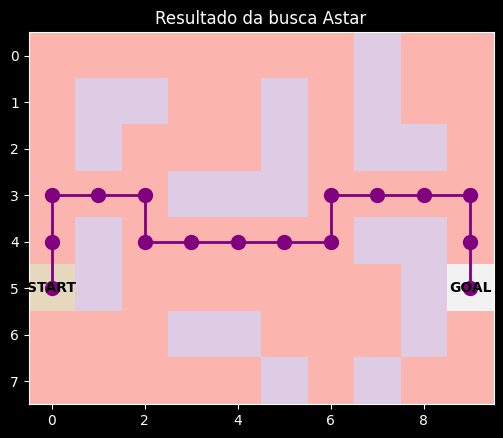

In [11]:
path_astar, metric_atar = a_star(grid_map, start_node, goal_node)
print(f"Análise A*, custo do caminho: {len(path_astar)-1}")
print(f"Esforço Computacional: {metric_atar}")
plot_search_result(grid_map, path=path_astar, title="Resultado da busca Astar")

1 -> Adicionar LAMA
2 -> Numero 5 = LAMA
3 -> new_g = 3 em vez de 1; SE encontrar LAMA g = 5 senao g = 1
4 -> Plot o caminho